In [1]:
import pandas as pd

data = pd.read_csv("Emotion_classify_Data[1].csv")

print(data.head())

                                             Comment Emotion
0  i seriously hate one subject to death but now ...    fear
1                 im so full of life i feel appalled   anger
2  i sit here to write i start to dig out my feel...    fear
3  ive been really angry with r and i feel like a...     joy
4  i feel suspicious if there is no one outside l...    fear


In [2]:
data.shape
data.columns
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5937 entries, 0 to 5936
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Comment  5937 non-null   str  
 1   Emotion  5937 non-null   str  
dtypes: str(2)
memory usage: 92.9 KB


,Comment,Emotion
count,5937,5937
unique,5934,3
top,i resorted to yesterday the post peak day of i...,anger
freq,2,2000


In [3]:
data.isnull().sum()
data.dropna(inplace=True)

In [4]:
data.drop_duplicates(inplace=True)

In [5]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

data['Comment'] = data['Comment'].apply(clean_text)

In [6]:
data['Emotion'].value_counts()

Emotion
anger    2000
joy      2000
fear     1937
Name: count, dtype: int64

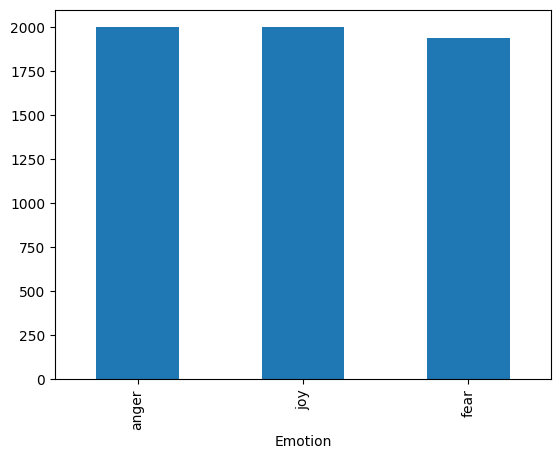

In [7]:
import matplotlib.pyplot as plt

data['Emotion'].value_counts().plot(kind='bar')
plt.show()

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(data['Comment'])   
y = data['Emotion']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MultinomialNB()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.8914141414141414


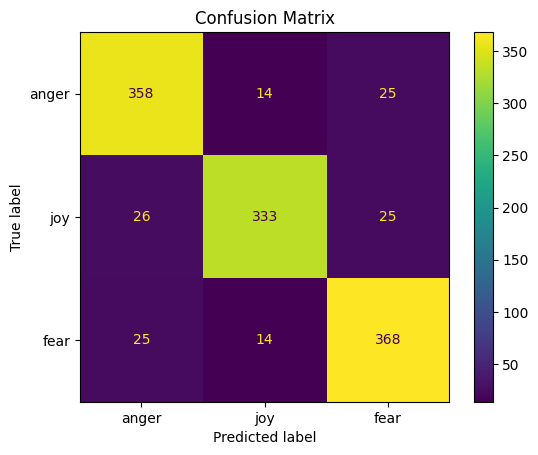

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=["anger", "joy", "fear"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["anger", "joy", "fear"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.88      0.90      0.89       397
        fear       0.88      0.90      0.89       407
         joy       0.92      0.87      0.89       384

    accuracy                           0.89      1188
   macro avg       0.89      0.89      0.89      1188
weighted avg       0.89      0.89      0.89      1188



In [12]:
new_texts = ["I am so happy today!", 
             "I am furious at what happened", 
             "Something feels very wrong and scary"]

new_X = vectorizer.transform(new_texts)
predictions = model.predict(new_X)

for text, emotion in zip(new_texts, predictions):
    print(f"Text: {text}")
    print(f"Predicted Emotion: {emotion}")
    print()

Text: I am so happy today!
Predicted Emotion: joy

Text: I am furious at what happened
Predicted Emotion: anger

Text: Something feels very wrong and scary
Predicted Emotion: fear



In [13]:
print("""
EMOTION DETECTION PROJECT - SUMMARY
=====================================

Dataset:
- 5937 text messages labeled with 3 emotions: anger, joy, fear

Model Used:
- Naive Bayes (MultinomialNB) with CountVectorizer

Results:
- Accuracy: 89%
- All three emotions scored 0.89 F1-score

Key Observations:
- Joy was the easiest emotion to detect (precision: 0.92)
- Anger and Fear were sometimes confused with each other
  because both are strong negative emotions
- The model predicts new unseen text correctly
""")


EMOTION DETECTION PROJECT - SUMMARY

Dataset:
- 5937 text messages labeled with 3 emotions: anger, joy, fear

Model Used:
- Naive Bayes (MultinomialNB) with CountVectorizer

Results:
- Accuracy: 89%
- All three emotions scored 0.89 F1-score

Key Observations:
- Joy was the easiest emotion to detect (precision: 0.92)
- Anger and Fear were sometimes confused with each other
  because both are strong negative emotions
- The model predicts new unseen text correctly

